# 05 — Portugal against the euro-area comparators

**Question.** Is Portugal's interest burden high, and if so, is that because it
borrows expensively or because it owes a lot?

**Panel.** The euro-area country universe plus two aggregates, built by
`pt-debt build-panel` from `config/default.yaml`. Every observation uses the
same Eurostat transaction, sector, and unit — that is the point of building the
panel rather than collecting published ratios.

**Reading rules.**

- Aggregates (the euro area, the EU) are context, not peers. They are drawn
  dashed and excluded from every ranking, which is what the panel's
  `is_aggregate` flag is for.
- A categorical palette carries eight hues. With twenty countries in the panel,
  a hue per country would be unreadable and would fail colour-vision checks, so
  a named handful carry colour and the rest recede to one neutral tone. The
  full numbers are always in the table beside the chart.

In [1]:
# Run correctly whether the kernel starts in notebooks/ or the repository root.
# Importing nbtools then puts src/ on the path, so pt_debt_interest is
# importable from a plain checkout without an editable install.
import sys
from pathlib import Path

_HERE = Path.cwd() if (Path.cwd() / "nbtools.py").is_file() else Path.cwd() / "notebooks"
if str(_HERE) not in sys.path:
    sys.path.insert(0, str(_HERE))

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import nbtools as nb
from pt_debt_interest.panel import aggregate_flag_mask
from pt_debt_interest.scenarios import comparator_rate_counterfactual

nb.use_style()
ROOT = nb.repo_root()

panel = nb.load_panel(ROOT)
panel["is_aggregate"] = aggregate_flag_mask(panel["is_aggregate"])
countries = panel.loc[~panel["is_aggregate"]]

HOME = "PT"
RATE = "average_debt_interest_rate_pct"
latest_year = int(panel["year"].max())
NAME = panel.drop_duplicates("geo").set_index("geo")["geo_name"].to_dict()

print(
    f"Geographies : {panel['geo'].nunique()} "
    f"({countries['geo'].nunique()} countries, "
    f"{panel.loc[panel['is_aggregate'], 'geo'].nunique()} aggregates)"
)
print(f"Years       : {int(panel['year'].min())}-{latest_year}")
print(f"Aggregates  : {', '.join(sorted(panel.loc[panel['is_aggregate'], 'geo'].unique()))}")

Geographies : 22 (20 countries, 2 aggregates)
Years       : 1995-2025
Aggregates  : EA20, EU27_2020


## 1. Coverage first

A comparison is only as good as the thinnest series in it, so the panel's
completeness is checked before anything is plotted.

In [3]:
compare_columns = [
    "interest_pct_gdp",
    "debt_pct_gdp",
    RATE,
    "ten_year_yield_pct",
    "primary_balance_pct_gdp",
]
coverage = panel.groupby(["geo", "geo_name"])[compare_columns].apply(
    lambda group: group.notna().sum()
)
coverage["years_in_panel"] = panel.groupby(["geo", "geo_name"]).size()
incomplete = coverage.loc[
    coverage[compare_columns].lt(coverage["years_in_panel"], axis=0).any(axis=1)
]
print(f"Geographies with a gap in any compared series: {len(incomplete)}")
incomplete if not incomplete.empty else coverage.head()

Geographies with a gap in any compared series: 22


,,interest_pct_gdp,debt_pct_gdp,average_debt_interest_rate_pct,ten_year_yield_pct,primary_balance_pct_gdp,years_in_panel
geo,geo_name,,,,,,
AT,Austria,31,31,30,31,31,31
BE,Belgium,31,31,30,31,31,31
CY,Cyprus,31,31,30,25,31,31
DE,Germany,31,31,30,31,31,31
EA20,Euro area - 20 countries,31,31,30,0,31,31
EE,Estonia,31,31,30,6,31,31
EL,Greece,31,31,30,31,31,31
ES,Spain,31,31,30,31,31,31
EU27_2020,European Union - 27 countries,31,26,25,25,31,31


## 2. The burden through time

Portugal and five reference economies carry colour; the euro-area aggregate is
dashed. The remaining countries are drawn in one neutral tone so the
distribution stays visible without pretending fifteen more hues would be
readable.

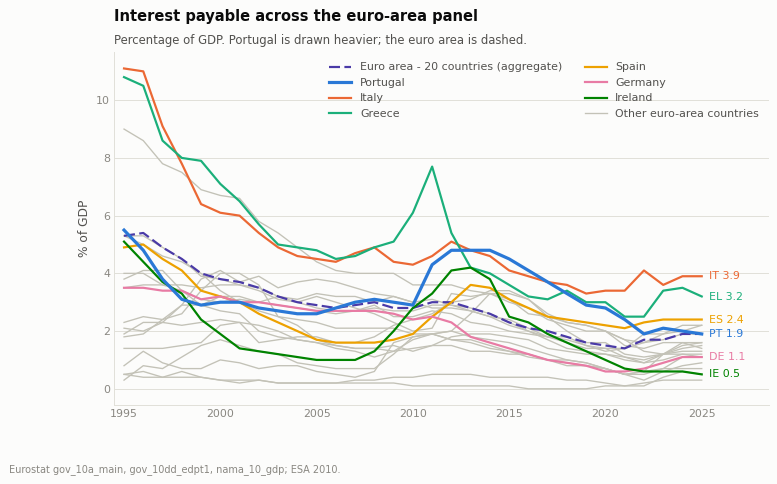

In [4]:
FEATURED = [HOME, "IT", "EL", "ES", "DE", "IE"]
CONTEXT = ["EA20"]
COLOR = nb.emphasis_palette([*FEATURED, *CONTEXT])

fig, ax = nb.figure(height=5.2)
for geo, group in panel.groupby("geo"):
    series = group.dropna(subset=["interest_pct_gdp"])
    if geo in COLOR:
        continue
    ax.plot(
        series["year"],
        series["interest_pct_gdp"],
        color=nb.RECEDED,
        linewidth=1.1,
        zorder=1,
    )
for geo in [*CONTEXT, *FEATURED]:
    series = panel.loc[panel["geo"].eq(geo)].dropna(subset=["interest_pct_gdp"])
    is_aggregate = bool(series["is_aggregate"].iloc[0])
    ax.plot(
        series["year"],
        series["interest_pct_gdp"],
        color=COLOR[geo],
        linewidth=2.6 if geo == HOME else 1.8,
        linestyle=(0, (5, 2)) if is_aggregate else "-",
        label=f"{NAME[geo]}{' (aggregate)' if is_aggregate else ''}",
        zorder=4 if geo == HOME else 3,
    )
    if geo in FEATURED:
        nb.label_last_point(
            ax, series["year"], series["interest_pct_gdp"], geo, COLOR[geo], "{:.1f}"
        )
ax.plot([], [], color=nb.RECEDED, linewidth=1.1, label="Other euro-area countries")
ax.set_xlim(panel["year"].min() - 0.5, latest_year + 3.5)
ax.legend(loc="upper right", ncol=2)
nb.finish(
    ax,
    title="Interest payable across the euro-area panel",
    subtitle="Percentage of GDP. Portugal is drawn heavier; the euro area is dashed.",
    ylabel="% of GDP",
    source="Eurostat gov_10a_main, gov_10dd_edpt1, nama_10_gdp; ESA 2010.",
)
plt.show()

## 3. Where Portugal sits in the latest year

A ranked bar chart is one series, so it takes one colour with Portugal
emphasised. Colouring bars by their own height would double-encode the length
they already show.

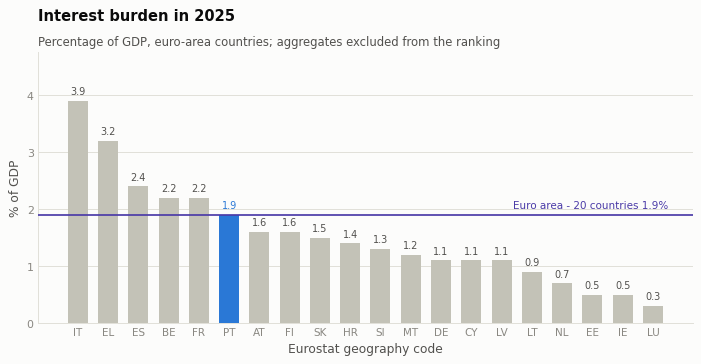

,interest_pct_gdp,debt_pct_gdp,average_debt_interest_rate_pct,interest_burden_rank,average_debt_rate_rank
geo_name,,,,,
Italy,3.90,137.10,2.87,1.00,1.00
Greece,3.20,146.10,2.15,2.00,9.00
Spain,2.40,100.70,2.43,3.00,6.00
Belgium,2.20,107.90,2.14,4.00,10.00
France,2.20,115.60,1.97,4.00,15.00
Portugal,1.90,89.70,2.18,6.00,8.00
Austria,1.60,81.50,2.03,7.00,12.00
Finland,1.60,88.50,1.92,7.00,16.00
Slovakia,1.50,61.40,2.62,9.00,3.00


In [5]:
snapshot = (
    countries.loc[countries["year"].eq(latest_year)]
    .dropna(subset=["interest_pct_gdp"])
    .sort_values("interest_pct_gdp", ascending=False)
)

fig, ax = nb.figure(height=4.0)
positions = np.arange(len(snapshot))
ax.bar(
    positions,
    snapshot["interest_pct_gdp"],
    color=nb.bar_colors(snapshot["geo"], HOME),
    width=0.66,
)
for position, (value, geo) in enumerate(
    zip(snapshot["interest_pct_gdp"], snapshot["geo"], strict=True)
):
    ax.annotate(
        f"{value:.1f}",
        xy=(position, value),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        fontsize=8,
        color=nb.SERIES[0] if geo == HOME else nb.SUBTLE,
    )
for aggregate in CONTEXT:
    level = panel.loc[
        panel["geo"].eq(aggregate) & panel["year"].eq(latest_year), "interest_pct_gdp"
    ]
    if not level.empty:
        ax.axhline(float(level.iloc[0]), color=COLOR[aggregate], linewidth=1.4, zorder=3)
        ax.annotate(
            f"{NAME[aggregate]} {float(level.iloc[0]):.1f}%",
            xy=(len(snapshot) - 0.5, float(level.iloc[0])),
            xytext=(0, 5),
            textcoords="offset points",
            ha="right",
            fontsize=8.5,
            color=COLOR[aggregate],
        )
ax.set_xticks(positions)
ax.set_xticklabels(snapshot["geo"], fontsize=8.5)
ax.set_ylim(0, snapshot["interest_pct_gdp"].max() * 1.22)
nb.finish(
    ax,
    title=f"Interest burden in {latest_year}",
    subtitle="Percentage of GDP, euro-area countries; aggregates excluded from the ranking",
    ylabel="% of GDP",
    xlabel="Eurostat geography code",
    source="",
)
plt.show()

snapshot.set_index("geo_name")[
    ["interest_pct_gdp", "debt_pct_gdp", RATE, "interest_burden_rank", "average_debt_rate_rank"]
]

## 4. Price or quantity?

The burden is the effective rate times the debt ratio, so a country can reach
the same burden from opposite directions. Plotting the two coordinates separates
the explanations, and curves of constant burden make the trade-off visible: any
point on a curve pays the same share of GDP.

Scatter marks are compared pairwise rather than in sequence, which is the case
where a categorical palette runs out fastest. So the marks take one colour with
Portugal emphasised, and only the featured economies and the extremes are
labelled — the table above carries every value.

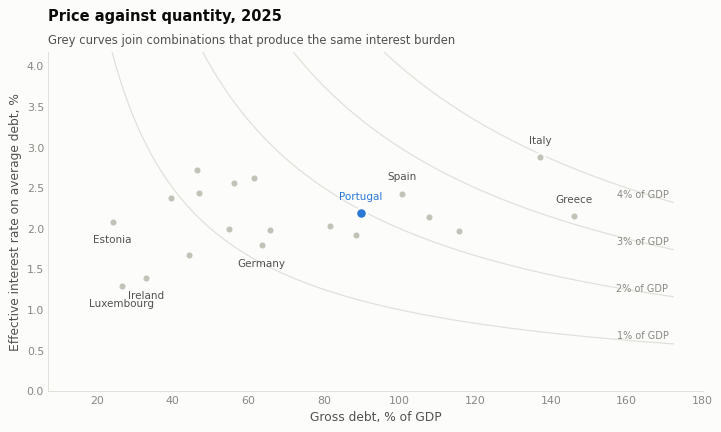

,value
Portugal debt (% GDP),89.70
median country debt (% GDP),62.40
Portugal effective rate (%),2.18
median country effective rate (%),2.11


In [6]:
scatter = countries.loc[countries["year"].eq(latest_year)].dropna(subset=[RATE, "debt_pct_gdp"])
labelled = set(FEATURED)
labelled.update(scatter.nlargest(2, "debt_pct_gdp")["geo"])
labelled.update(scatter.nsmallest(2, "debt_pct_gdp")["geo"])
labelled.update(scatter.nlargest(1, RATE)["geo"])
labelled.update(scatter.nsmallest(1, RATE)["geo"])

median_rate = scatter[RATE].median()

fig, ax = nb.figure(height=5.0)
grid_debt = np.linspace(15, scatter["debt_pct_gdp"].max() * 1.18, 200)
for burden in (1.0, 2.0, 3.0, 4.0):
    ax.plot(grid_debt, burden / grid_debt * 100.0, color=nb.GRID, linewidth=1.0, zorder=0)
    ax.annotate(
        f"{burden:.0f}% of GDP",
        xy=(grid_debt[-1], burden / grid_debt[-1] * 100.0),
        xytext=(-4, 4),
        textcoords="offset points",
        fontsize=8,
        color=nb.MUTED,
        ha="right",
    )

for _, row in scatter.iterrows():
    is_home = row["geo"] == HOME
    ax.plot(
        row["debt_pct_gdp"],
        row[RATE],
        marker="o",
        markersize=9 if is_home else 7,
        color=nb.SERIES[0] if is_home else nb.RECEDED,
        markeredgecolor=nb.SURFACE,
        markeredgewidth=2.0,
        zorder=4 if is_home else 3,
    )
    if row["geo"] in labelled:
        above = row[RATE] >= median_rate
        ax.annotate(
            row["geo_name"],
            xy=(row["debt_pct_gdp"], row[RATE]),
            xytext=(0, 11 if above else -17),
            textcoords="offset points",
            ha="center",
            fontsize=8.5,
            color=nb.SERIES[0] if is_home else nb.SUBTLE,
        )

ax.set_ylim(0, scatter[RATE].max() * 1.45)
ax.grid(False)
nb.finish(
    ax,
    title=f"Price against quantity, {latest_year}",
    subtitle="Grey curves join combinations that produce the same interest burden",
    ylabel="Effective interest rate on average debt, %",
    xlabel="Gross debt, % of GDP",
    source="",
)
plt.show()

pd.Series(
    {
        "Portugal debt (% GDP)": round(
            float(scatter.loc[scatter["geo"].eq(HOME), "debt_pct_gdp"].iloc[0]), 1
        ),
        "median country debt (% GDP)": round(scatter["debt_pct_gdp"].median(), 1),
        "Portugal effective rate (%)": round(
            float(scatter.loc[scatter["geo"].eq(HOME), RATE].iloc[0]), 2
        ),
        "median country effective rate (%)": round(scatter[RATE].median(), 2),
    },
    name="value",
).to_frame()

## 5. Repricing Portugal's debt at a comparator's cost

The counterfactual holds Portugal's debt ratio fixed and applies each
comparator's effective rate. It isolates the price of the debt from its size,
and it is explicitly *not* a forecast: a different rate would have come with
different fiscal and market conditions, and so with a different debt ratio.

In [7]:
home = panel.loc[panel["geo"].eq(HOME)].set_index("year")
counterfactual = pd.concat(
    [
        comparator_rate_counterfactual(
            home["debt_pct_gdp"],
            home[RATE],
            panel.loc[panel["geo"].eq(geo)].set_index("year")[RATE],
        ).rename(geo)
        for geo in sorted(panel["geo"].unique())
    ],
    axis=1,
)

latest_counterfactual = counterfactual.loc[latest_year].rename("burden_pct_gdp").to_frame()
latest_counterfactual["geo_name"] = [NAME[geo] for geo in latest_counterfactual.index]
latest_counterfactual["effective_rate_pct"] = [
    float(panel.loc[panel["geo"].eq(geo) & panel["year"].eq(latest_year), RATE].iloc[0])
    for geo in latest_counterfactual.index
]
actual_burden = float(home.loc[latest_year, "interest_pct_gdp"])
latest_counterfactual["difference_pp"] = latest_counterfactual["burden_pct_gdp"] - actual_burden

print(
    f"Portugal actually paid {actual_burden:.1f}% of GDP in {latest_year} on debt of "
    f"{home.loc[latest_year, 'debt_pct_gdp']:.1f}% of GDP."
)
latest_counterfactual.set_index("geo_name").sort_values("burden_pct_gdp")[
    ["effective_rate_pct", "burden_pct_gdp", "difference_pp"]
]

Portugal actually paid 1.9% of GDP in 2025 on debt of 89.7% of GDP.


,effective_rate_pct,burden_pct_gdp,difference_pp
geo_name,,,
Luxembourg,1.30,1.16,-0.74
Ireland,1.40,1.25,-0.65
Netherlands,1.67,1.50,-0.40
Germany,1.79,1.61,-0.29
Finland,1.92,1.72,-0.18
France,1.97,1.77,-0.13
Slovenia,1.98,1.77,-0.13
Cyprus,1.99,1.78,-0.12
Austria,2.03,1.82,-0.08


Portugal's own row is a useful control. It does not reproduce the published
burden exactly, and the gap is the arithmetic of the counterfactual rather than
an error: it multiplies the *end-year* debt ratio by an effective rate computed
on *average* debt over the year. That difference sets the resolution of this
comparison — gaps between comparators smaller than it should not be read as
meaningful.

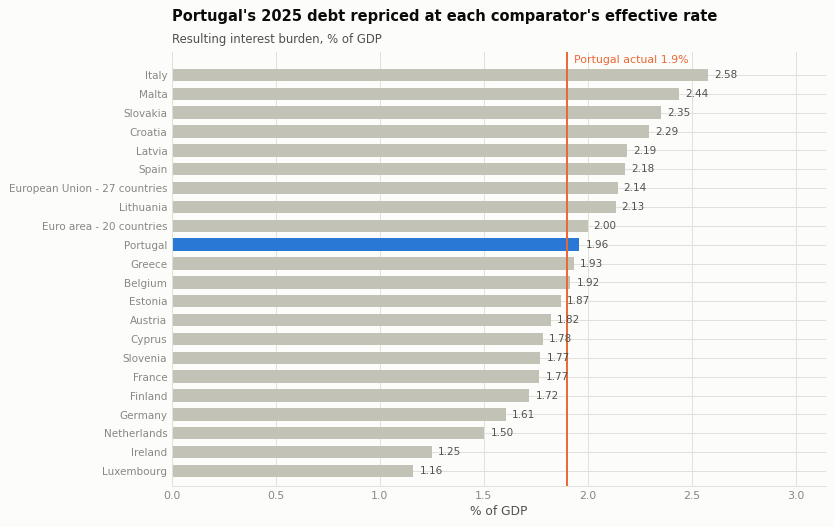

In [8]:
ordered = latest_counterfactual.sort_values("burden_pct_gdp")

fig, ax = nb.figure(height=6.4)
positions = np.arange(len(ordered))
ax.barh(
    positions,
    ordered["burden_pct_gdp"],
    color=nb.bar_colors(ordered.index, HOME),
    height=0.66,
)
ax.axvline(actual_burden, color=nb.SERIES[1], linewidth=1.6, zorder=3)
ax.annotate(
    f"Portugal actual {actual_burden:.1f}%",
    xy=(actual_burden, len(ordered) - 0.2),
    xytext=(6, 0),
    textcoords="offset points",
    fontsize=9,
    color=nb.SERIES[1],
    va="center",
)
for position, value in enumerate(ordered["burden_pct_gdp"]):
    ax.annotate(
        f"{value:.2f}",
        xy=(value, position),
        xytext=(5, 0),
        textcoords="offset points",
        va="center",
        fontsize=8.5,
        color=nb.SUBTLE,
    )
ax.set_yticks(positions)
ax.set_yticklabels(ordered["geo_name"], fontsize=8.5)
ax.set_xlim(0, ordered["burden_pct_gdp"].max() * 1.22)
ax.set_ylim(-0.8, len(ordered) + 0.2)
ax.grid(axis="x")
nb.finish(
    ax,
    title=f"Portugal's {latest_year} debt repriced at each comparator's effective rate",
    subtitle="Resulting interest burden, % of GDP",
    xlabel="% of GDP",
    source="",
)
plt.show()

## 6. Convergence in the price of debt

The spread between Portugal's effective rate and Germany's is the cleanest
single summary of how the market has repriced Portuguese sovereign risk — and of
how slowly that repricing reaches the debt stock, which is the lag notebook 04
estimated.

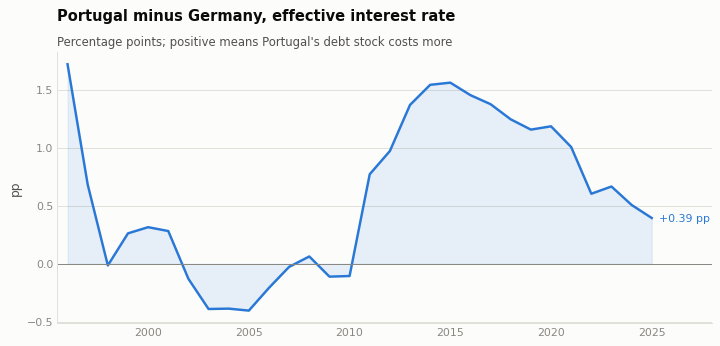

,value
widest spread (pp),1.72
widest spread year,"1,996.00"
narrowest spread (pp),-0.41
narrowest spread year,"2,005.00"
latest spread (pp),0.39


In [9]:
wide_rate = panel.pivot(index="year", columns="geo", values=RATE)
spread = (wide_rate[HOME] - wide_rate["DE"]).dropna()

fig, ax = nb.figure(height=4.0)
ax.plot(spread.index, spread.to_numpy(), color=nb.SERIES[0])
ax.fill_between(spread.index, 0, spread.to_numpy(), color=nb.SERIES[0], alpha=0.10)
ax.axhline(0, color=nb.MUTED, linewidth=0.8)
nb.label_last_point(ax, spread.index, spread.to_numpy(), "", nb.SERIES[0], "{:+.2f} pp")
ax.set_xlim(spread.index.min() - 0.5, spread.index.max() + 3.0)
nb.finish(
    ax,
    title="Portugal minus Germany, effective interest rate",
    subtitle="Percentage points; positive means Portugal's debt stock costs more",
    ylabel="pp",
    source="",
)
plt.show()

pd.Series(
    {
        "widest spread (pp)": round(spread.max(), 2),
        "widest spread year": int(spread.idxmax()),
        "narrowest spread (pp)": round(spread.min(), 2),
        "narrowest spread year": int(spread.idxmin()),
        "latest spread (pp)": round(spread.iloc[-1], 2),
    },
    name="value",
).to_frame()

## 7. Rank by burden against rank by price

The two ranks are the sharpest form of the price-or-quantity question. If
Portugal ranks worse on burden than on effective rate, the gap is the debt
stock. Both are computed by the pipeline across non-aggregate countries only.

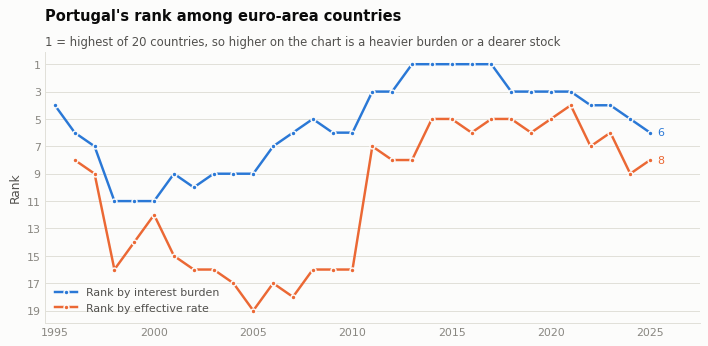

,interest_burden_rank,average_debt_rate_rank
year,,
2018,3.00,5.00
2019,3.00,6.00
2020,3.00,5.00
2021,3.00,4.00
2022,4.00,7.00
2023,4.00,6.00
2024,5.00,9.00
2025,6.00,8.00


In [10]:
rank_columns = {
    "interest_burden_rank": ("Rank by interest burden", nb.SERIES[0]),
    "average_debt_rate_rank": ("Rank by effective rate", nb.SERIES[1]),
}
ranks = countries.loc[countries["geo"].eq(HOME)].set_index("year")[list(rank_columns)]
ranked_countries = int(
    countries.pivot(index="year", columns="geo", values="interest_burden_rank")
    .notna()
    .sum(axis=1)
    .max()
)

fig, ax = nb.figure(height=4.0)
for column, (label, color) in rank_columns.items():
    series = ranks[column].dropna()
    ax.plot(
        series.index,
        series.to_numpy(),
        color=color,
        marker="o",
        markersize=4,
        markeredgecolor=nb.SURFACE,
        markeredgewidth=1.2,
        label=label,
    )
    nb.label_last_point(ax, series.index, series.to_numpy(), "", color, "{:.0f}")
ax.invert_yaxis()
# Ranks are integers; the default locator would offer half-places.
ax.set_yticks(range(1, ranked_countries + 1, 2))
ax.set_xlim(ranks.index.min() - 0.5, ranks.index.max() + 2.5)
ax.legend(loc="lower left")
nb.finish(
    ax,
    title="Portugal's rank among euro-area countries",
    subtitle=(
        f"1 = highest of {ranked_countries} countries, so higher on the chart "
        "is a heavier burden or a dearer stock"
    ),
    ylabel="Rank",
    source="",
)
plt.show()

ranks.tail(8)

## 8. Findings

In [11]:
home_snapshot = snapshot.loc[snapshot["geo"].eq(HOME)].iloc[0]
cheapest = latest_counterfactual.sort_values("burden_pct_gdp").iloc[0]
dearest = latest_counterfactual.sort_values("burden_pct_gdp").iloc[-1]
debt_rank = int(
    snapshot["debt_pct_gdp"].rank(ascending=False, method="min").loc[home_snapshot.name]
)

print(
    f"In {latest_year} Portugal paid {home_snapshot['interest_pct_gdp']:.1f}% of GDP, "
    f"rank {int(home_snapshot['interest_burden_rank'])} of {ranked_countries}."
)
print(
    f"  effective rate {home_snapshot[RATE]:.2f}% -> rank "
    f"{int(home_snapshot['average_debt_rate_rank'])}; "
    f"debt {home_snapshot['debt_pct_gdp']:.1f}% of GDP -> rank {debt_rank}"
)
print(
    f"  median country: debt {snapshot['debt_pct_gdp'].median():.1f}% of GDP, "
    f"effective rate {snapshot[RATE].median():.2f}%"
)
print(
    f"At {cheapest['geo_name']}'s effective rate the same debt would cost "
    f"{cheapest['burden_pct_gdp']:.2f}% of GDP ({cheapest['difference_pp']:+.2f} pp)."
)
print(
    f"At {dearest['geo_name']}'s effective rate it would cost "
    f"{dearest['burden_pct_gdp']:.2f}% of GDP ({dearest['difference_pp']:+.2f} pp)."
)
print(
    f"Portugal-Germany effective-rate spread: {spread.max():.2f} pp at its widest "
    f"({int(spread.idxmax())}), {spread.iloc[-1]:+.2f} pp in {int(spread.index[-1])}."
)

In 2025 Portugal paid 1.9% of GDP, rank 6 of 20.
  effective rate 2.18% -> rank 8; debt 89.7% of GDP -> rank 6
  median country: debt 62.5% of GDP, effective rate 2.11%
At Luxembourg's effective rate the same debt would cost 1.16% of GDP (-0.74 pp).
At Italy's effective rate it would cost 2.58% of GDP (+0.68 pp).
Portugal-Germany effective-rate spread: 1.72 pp at its widest (1996), +0.39 pp in 2025.


**Reading.** Portugal's position in the panel is driven far more by the quantity
of debt than by its price. Its effective rate now sits close to the middle of
the euro-area distribution, so repricing the stock at a peer's rate moves the
burden by a fraction of a point of GDP in either direction — while the debt
ratio remains among the higher ones in the group. The two ranks in section 7 say
the same thing directly: the burden rank is worse than the rate rank, and the
difference is the stock. That is the conclusion notebook 03 reached from
Portuguese data alone, arrived at from a different direction.

**Caveats.** Ranks say nothing about the distance between neighbouring
countries — several are separated by a tenth of a point of GDP, within the
resolution flagged in section 5. Effective rates mix market debt with official
and programme lending on non-market terms, which matters for Greece, Ireland,
Cyprus, and Portugal in the adjustment years. Small member states with low debt
ratios have effective rates that move sharply on small absolute changes. And the
counterfactual varies one input while holding everything else fixed: it is an
arithmetic comparison, not a claim about what would have happened.